In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from langgraph.graph import START, END , StateGraph
from langchain_groq  import ChatGroq
from pydantic import BaseModel
from  langgraph.types import interrupt , Command
from langgraph.checkpoint.memory import InMemorySaver 
from typing import Literal

In [ ]:
class  MainState(BaseModel):
    query :str =""
    draft: str =""
    humman_feedback : str = ""
    final_response : str =""
    

In [ ]:
model = ChatGroq(model="openai/gpt-oss-20b")


In [ ]:
def DraftEmail(state:MainState)-> MainState:
    if state.humman_feedback:
        state.draft = model.invoke(f"""
            Rewrite this draft for { state.query }
            You Have Generated this mail :  {state.draft},
            Humman FeedBack to apply : {state.humman_feedback},
            
        """).content
    else:
        draft = model.invoke(state.query).content
        state.draft = draft
    return state


In [ ]:
def  HummanInLoop(state:MainState) -> MainState:
    feedback = interrupt({
        "draft_email" :  state.draft,
        "question": "Do you want to continue or re-write the mail"
    })

    fb = (feedback or "").strip().lower()
    if fb in ("approved" , "ok" , "yes"):
        state.humman_feedback =""
        return state
    else:
        state.humman_feedback = feedback
        return state

In [ ]:
def FinalizeNode(state:MainState)->MainState:
    if state.humman_feedback:
        state.final_response = state.humman_feedback
        return state
    else:
        print("Emain Sent")
        state.final_response= "Sent Successfylly"
        return state

In [ ]:
def conditinal_routing(state:MainState)-> Literal["draft" , "final"]:
    if state.humman_feedback:
        return "draft"
    return "final"

In [ ]:

app =  StateGraph(MainState)

app.add_node("draft" , DraftEmail)
app.add_node("humman_fb" , HummanInLoop)
app.add_node("final" , FinalizeNode)

app.add_edge(START , "draft")
app.add_edge("draft" , "humman_fb")
app.add_conditional_edges( "humman_fb" , conditinal_routing)
app.add_edge("final" , END)

app = app.compile(checkpointer= InMemorySaver())

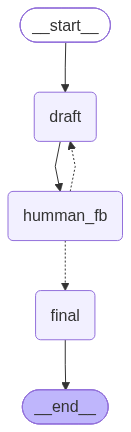

In [ ]:
app

In [ ]:
config = {"configurable":{"thread_id":"my-bot-1"}}


In [ ]:
res = app.invoke({"query" : "I want to send main for medical Leave"} , config= config)

In [ ]:
print(res["draft"])

Below is a ready‑to‑use **medical‑leave request letter** that you can copy, adapt, and email (or print) to your supervisor/HR.  
Feel free to tweak the dates, tone, or any details to fit your workplace’s style.

---

### Medical‑Leave Request – Email / Letter Template

**Subject:** Medical Leave Request – [Your Full Name] – [Start Date] to [End Date]  

---

**Dear [Supervisor’s Name],**

I am writing to formally request medical leave from **[Start Date]** through **[End Date]** due to a medical condition that requires treatment and recovery.  

**Reason for Leave**  
(Briefly explain the nature of your medical issue – you may keep it general if you prefer privacy.)  
> *Example:* “I am undergoing a scheduled procedure and will need time for post‑operative recovery.”

**Duration**  
I anticipate needing **[number]** days of leave, which includes the treatment date(s) and the recovery period. I will keep you updated if the timeline changes.

**Work Arrangements**  
To minimize disruptio

In [ ]:
res= app.invoke(Command(resume="yes") , config= config)

Emain Sent


In [ ]:
print(res["draft"])

Below is a ready‑to‑use **medical‑leave request letter** that you can copy, adapt, and email (or print) to your supervisor/HR.  
Feel free to tweak the dates, tone, or any details to fit your workplace’s style.

---

### Medical‑Leave Request – Email / Letter Template

**Subject:** Medical Leave Request – [Your Full Name] – [Start Date] to [End Date]  

---

**Dear [Supervisor’s Name],**

I am writing to formally request medical leave from **[Start Date]** through **[End Date]** due to a medical condition that requires treatment and recovery.  

**Reason for Leave**  
(Briefly explain the nature of your medical issue – you may keep it general if you prefer privacy.)  
> *Example:* “I am undergoing a scheduled procedure and will need time for post‑operative recovery.”

**Duration**  
I anticipate needing **[number]** days of leave, which includes the treatment date(s) and the recovery period. I will keep you updated if the timeline changes.

**Work Arrangements**  
To minimize disruptio